# Libraries

In [26]:
import numpy as np
import pandas as pd
import autokeras as ak
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import joblib as jl

from sklearn.model_selection import train_test_split
from keras.models import load_model
from tensorflow.keras.models import Model
from tensorflow.keras.models import clone_model
from scipy.stats import pearsonr, gaussian_kde
from time import time

# Functions

In [2]:
def build_mc_dropout_model(model, factor=1, replace_bn=True):
    def clone_fn(layer):
        if isinstance(layer, tf.keras.layers.Dropout):
            if len(layer.input_shape) == 3:
                return tf.keras.layers.SpatialDropout1D(rate=layer.rate * factor)
        
        if replace_bn is True:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                return tf.keras.layers.LayerNormalization(
                    axis=-1,
                    epsilon=layer.epsilon,
                    center=True,
                    scale=True,
                    name=layer.name.replace( 'batch_normalization', 'layer_normalization' )
                )
        
        return layer

    new_model = tf.keras.models.clone_model(model, clone_function=clone_fn)
    
    input_layer = new_model.input
    y_predicted = new_model(input_layer, training=True)
    mc_dropout_model = Model(
        name='mc_dropout_model',
        inputs=input_layer,
        outputs=y_predicted
    )
    
    return mc_dropout_model

In [13]:
def DNN_uncertainity(model, x_test, T=500, multitasking=False):
     
    if multitasking == False:
        predictions = []
    elif multitasking == True:
        predictions_1 = []
        predictions_2 = []
        
    for _ in range(T):
        if multitasking == False:
            #predictions += [ model(x_test, training=True) ]
            predictions += [ model( x_test ) ]
        elif multitasking == True:
            #predictions_aux = model(x_test, training=True)
            predictions_aux = model( x_test )
            predictions_1 += [ predictions_aux[0] ]
            predictions_2 += [ predictions_aux[1] ]
    
    if multitasking == False:
        predictions = np.array( predictions )
        
        return predictions
    
    elif multitasking == True:
        predictions_1 = np.array( predictions_1 )
        predictions_2 = np.array( predictions_2 )
        
        return predictions_1, predictions_2

def inverse_scaler(scaler, data_normalized):
    
    number_test = data_normalized.shape[1]
    data = np.zeros(data_normalized.shape)
    for i in range(number_test):
        data[:, i, :] = scaler.inverse_transform( data_normalized[:, i, :] )
    
    return data

In [4]:
def predict(prediction_parameters):
    try:
        model = prediction_parameters['model']
        X = prediction_parameters['X']
        y_scaler = prediction_parameters['y_scaler']
    except KeyError as error:
        raise ValueError(f'Missing required parameter: {error.args[0]}')
    
    number_predictions = X.shape[0]
    
    X_in_shape = prediction_parameters.get( 'X_in_shape' )
    x_scaler = prediction_parameters.get( 'x_scaler' )
    feature_extractor = prediction_parameters.get( 'feature_extractor' )
    forward_passes = prediction_parameters.get( 'fordward_passes', 500 )
    multitasking = prediction_parameters.get( 'multitasking', False )
    batch_inference = prediction_parameters.get( 'batch_inference', number_predictions )
    
    if x_scaler is not None:
        X.shape = ( number_predictions, x_scaler.n_features_in_ )
        X = x_scaler.transform( X )
    if X_in_shape is not None:
        X.shape = X_in_shape
    if feature_extractor is not None:
        X_ = np.zeros( (number_predictions, *feature_extractor.output_shape[1:]) )
        for i in range( 0, number_predictions, batch_inference ):
            X_[i:i + batch_inference] = feature_extractor( X[i:i + batch_inference] )
        X = X_
        del X_
    
    y_predicted_normalized = np.zeros( (forward_passes, number_predictions, *model.output_shape[1:]) )
    for i in range( 0, number_predictions, batch_inference ):
        y_predicted_normalized[:, i:i + batch_inference] = DNN_uncertainity(
            model,
            X[i:i + batch_inference],
            T=forward_passes,
            multitasking=multitasking
        )
    
    y_predicted = inverse_scaler( y_scaler, y_predicted_normalized )
    
    results_parameters = {
        'y_predicted': y_predicted
    }
    
    return results_parameters

def analysis(results_parameters):
    try:
        y_predicted = results_parameters['y_predicted']
    except KeyError as error:
        raise ValueError(f'Missing required parameter: {error.args[0]}')
    
    y_expected = results_parameters.get( 'y_expected' )
    y_scaler = results_parameters.get( 'y_scaler' )
    
    y_median = np.median( y_predicted, axis=0 )
    y_q1 = np.quantile( y_predicted, 0.25, axis=0 )
    y_q3 = np.quantile( y_predicted, 0.75, axis=0 )
    
    statistics_parameters = {
        'y_predicted': y_predicted,
        'y_median': y_median,
        'y_q1': y_q1,
        'y_q3': y_q3,
    }
    
    if y_expected is not None:
        if y_scaler is not None:
            y_expected = y_scaler.inverse_transform( y_expected )
        statistics_parameters['y_expected'] = y_expected
        
        spc = np.array(
            list(
                map(
                    pearsonr,
                    y_median.T,
                    y_expected.T
                )
            )
        )[:, 0]**2
        rmse = np.sqrt( np.mean( ( y_predicted - y_expected )**2, axis=(0, 1) ) )
        rmsre = np.sqrt( np.mean( ( ( y_predicted - y_expected ) / y_expected )**2, axis=(0, 1) ) )
        
        statistics_parameters['spc'] = spc
        statistics_parameters['rmse'] = rmse
        statistics_parameters['rmsre'] = rmsre
    
    return statistics_parameters

def results(statistics_parameters):
    try:
        y_median = statistics_parameters['y_median']
        y_q1 = statistics_parameters['y_q1']
        y_q3 = statistics_parameters['y_q3']
    except KeyError as error:
        raise ValueError(f'Missing required parameter: {error.args[0]}')
    
    y_expected = statistics_parameters.get( 'y_expected' )
    labels = statistics_parameters.get( 'labels' )
    suptitle = statistics_parameters.get( 'suptitle' )
    save = statistics_parameters.get( 'save' )
    fontsize = statistics_parameters.get( 'fontsize', {} )
    
    fontsize_label = fontsize.get( 'label', 15 )
    fontsize_ticks = fontsize.get( 'ticks', 15 )
    fontsize_title = fontsize.get( 'title', 15 )
    fontsize_suptitle = fontsize.get( 'suptitle', 15 )
    fontsize_legend = fontsize.get( 'legend', 15 )
    
    number_parameters = y_median.shape[1]
    
    y_uncertainty = np.array([
        y_median - y_q1,
        y_q3 - y_median
    ])
    
    steps = np.array([ 1, 2, 5, 10 ])
    bandwidth = 'silverman'
    
    scale_factor = 0.40
    fig, ax = plt.subplots(
        2,
        number_parameters,
        figsize=( 10 * scale_factor * number_parameters, 7 * scale_factor * 2 ),
        constrained_layout=True,
        sharex='col'
    )
    
    for i in range( number_parameters ):
        y_median_selected = y_median[:, i]
        y_uncertainty_selected = y_uncertainty[:, :, i]
        
        kernel_median = gaussian_kde(y_median_selected, bw_method=bandwidth)
        if y_expected is not None:
            y_expected_selected = y_expected[:, i]
            kernel_expected = gaussian_kde(y_expected_selected, bw_method=bandwidth)
            
            y_min = np.min( np.concatenate( (y_median_selected, y_expected_selected) ) )
            y_max = np.max( np.concatenate( (y_median_selected, y_expected_selected) ) )
        else:
            y_min = np.min( y_median_selected )
            y_max = np.max( y_median_selected )
        
        y_min = y_min - (y_max - y_min) * 0.1
        y_max = y_max + (y_max - y_min) * 0.1
        y_evaluate = np.linspace( y_min, y_max, 200 )
        
        ax[0, i].plot(
            y_evaluate,
            kernel_median(y_evaluate),
            c='b',
            label='Pred.'
        )
        
        ax[1, i].plot(
            [-1e10, 1e10],
            [-1e10, 1e10],
            c='gray'
        )
        
        if y_expected is not None:
            ax[0, i].plot(
                y_evaluate,
                kernel_expected(y_evaluate),
                c='black',
                label='Exp.'
            )
            
            ax[0, i].set_title(
                '$R^2$ = ' + f'{statistics_parameters["spc"][i]:0.4f}; ' +
                f'RMSRE = {statistics_parameters["rmsre"][i]:0.2f}\n' +
                f'RMSE = {statistics_parameters["rmse"][i]:0.2f}\n',
                fontsize=fontsize_title
            )
            
            ax[0, i].tick_params( axis='both', labelsize=fontsize_ticks )
            
            ax[0, i].ticklabel_format( axis='both', style='scientific', scilimits=(-2, 2) )
            ax[0, i].xaxis.get_offset_text().set_size(fontsize_ticks)
            ax[0, i].yaxis.get_offset_text().set_size(fontsize_ticks)
            
            ax[0, i].xaxis.set_major_locator( ticker.MaxNLocator( nbins=8, steps=steps ) )
            ax[0, i].yaxis.set_major_locator( ticker.MaxNLocator( nbins=8, steps=steps ) )
            
            ax[1, i].errorbar(
                y_expected_selected,
                y_median_selected,
                yerr=y_uncertainty_selected,
                fmt='r.',
                markersize=7,
            )
            
            ax[1, i].set_xlim( y_min, y_max )
            ax[1, i].set_ylim( y_min, y_max )
            
            ax[1, i].tick_params(axis='both', labelsize=fontsize_ticks)
            
            ax[1, i].ticklabel_format( axis='both', style='scientific', scilimits=(-2, 2) )
            ax[1, i].xaxis.get_offset_text().set_size(fontsize_ticks)
            ax[1, i].yaxis.get_offset_text().set_size(fontsize_ticks)
            
            ax[1, i].xaxis.set_major_locator( ticker.MaxNLocator( nbins=8, steps=steps ) )
            ax[1, i].yaxis.set_major_locator( ticker.MaxNLocator( nbins=8, steps=steps ) )
            
        if labels is not None:
            ax[1, i].set_ylabel( f'{labels[i]} (exp.)', fontsize=fontsize_label )
            ax[1, i].set_xlabel( f'{labels[i]} (pred.)', fontsize=fontsize_label )
    
    ax[0, 0].set_ylabel( 'Density', fontsize=fontsize_label )
    ax[0, 0].legend( fontsize=fontsize_legend )
    
    if suptitle is not None:
        fig.suptitle( suptitle, fontsize=fontsize_suptitle )
    
    if save is not None:
        plt.savefig( save, dpi=300 )
        statistics_parameters['save'] = None
    
    plt.show()
    plt.close()

# Data

In [16]:
labels = np.array([
    r'$T_\mathrm{eff}\,(\mathrm{K})$',
    r'$\log{g}\,(\mathrm{dex})$',
    r'$\log{Q}$'
])

## Synthetic

Synthetic stellar spectra, sampled from ISOSCELES database (size ~ 10%). From this sample, 80% was used for training. Only the testing dataset is imported.

In [35]:
X_test = np.load( '../ENSEMBLE/X_testing.npy', mmap_mode='r' )
X_in_shape = X_test.shape
y_test = np.load( '../ENSEMBLE/y_testing.npy', mmap_mode='r' )

print( X_test.shape, y_test.shape )

(74137, 2200) (74137, 3)


## Observed (deconvolved)

329 stellar spectra (main sequence O-type stars) from the IACOB database, along with estimated parameters, provided by Sergio Simón-Díaz.

In [36]:
X_observed = np.load( '../data/deconvolved/flux_IACOB_329_O_stars.npy' )
parameters_observed = pd.read_csv( '../data/IACOB/parameters_IACOB.csv' )
parameters_observed = parameters_observed[ ['TEFF', 'LOGG', 'LOGQ'] ].values

print( X_observed.shape, parameters_observed.shape )

(329, 11, 200) (329, 3)


80% of this sampled was used for training with a domain adaptation technique (Supervised Domain Adversarial Training), thus only the remaining 20% is used for testing.

In [37]:
seed_ = 42
X_observed_train, X_observed_test, parameters_observed_train, parameters_observed_test = train_test_split(
    X_observed, parameters_observed, shuffle = True, test_size=0.20, random_state=seed_
)

X_in_shape_observed = ( X_observed_test.shape[0], X_observed_test.shape[1] * X_observed_test.shape[2] )

print( X_observed_test.shape, y_observed_test.shape )

del X_observed_train, parameters_observed_train

(66, 11, 200) (66, 3)


# Models

Models to scale the input (stellar spectra, for the feature extractor) and the output (parameters, to account for the different magnitudes of the data).

In [8]:
x_scaler = jl.load( '../models/feature_extractor_tgq/x_scaler.gz' )
y_scaler = jl.load( '../ENSEMBLE/y_scaler.gz' )

y_observed_test = y_scaler.transform( parameters_observed_test )

Deep Neural Network models to extract revelant features from stellar spectra (feature exctractor) and to estimate stellar and wind parameters from said features (MC Dropout model). These models were trained using only synthetic data.

In [45]:
feature_extractor = load_model( '../models/feature_extractor_tgq' ).encoder
task_head = load_model( '../models/task_head_tgq' )
mc_dropout_model = build_mc_dropout_model( task_head, factor=1, replace_bn=False )

Model containing weights for the feature extractor and the MC Dropout trained with a domain adaptation technique, using both synthetic and observed data.

In [39]:
domain_adaptation_model = load_model( '../models/dann_results/dann_1' )

# Predictions

## Without domain adaptation

Predictions for synthetic testing data:

In [29]:
prediction_parameters = {
    'model': mc_dropout_model,
    'X': X_test,
    'y_scaler': y_scaler,
    'X_in_shape': X_in_shape,
    'x_scaler': x_scaler,
    'feature_extractor': feature_extractor,
    'fordward_passes': 500,
    'batch_inference': 2**12 # 4096
}

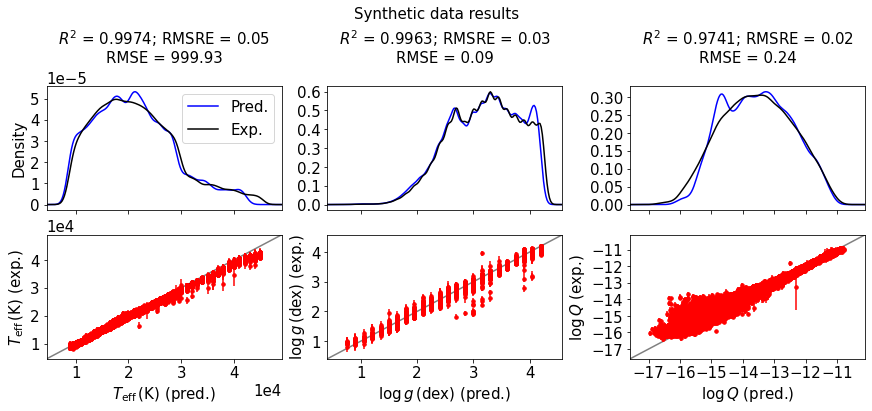

Execution time: 17.8252 (min)


In [30]:
time_start = time()
results_parameters = predict(prediction_parameters)
time_end = time()
results_parameters['y_expected'] = y_test
results_parameters['y_scaler'] = y_scaler
statistics_parameters = analysis(results_parameters)

statistics_parameters['labels'] = labels
statistics_parameters['suptitle'] = 'Synthetic data results'
statistics_parameters['save'] = None
results(statistics_parameters)

print( f'Execution time: {( time_end - time_start )/60:0.4f} (min)' )

The models takes 17.8252 minutes for 74 137 models. This equates to ~ 0.01 seconds per model.

Predictions for deconvolved observed spectra:

In [46]:
prediction_parameters = {
    'model': mc_dropout_model,
    'X': X_observed_test,
    'y_scaler': y_scaler,
    'X_in_shape': X_in_shape_observed,
    'x_scaler': x_scaler,
    'feature_extractor': feature_extractor,
    'fordward_passes': 500,
    'batch_inference': 2**12 # 4096
}

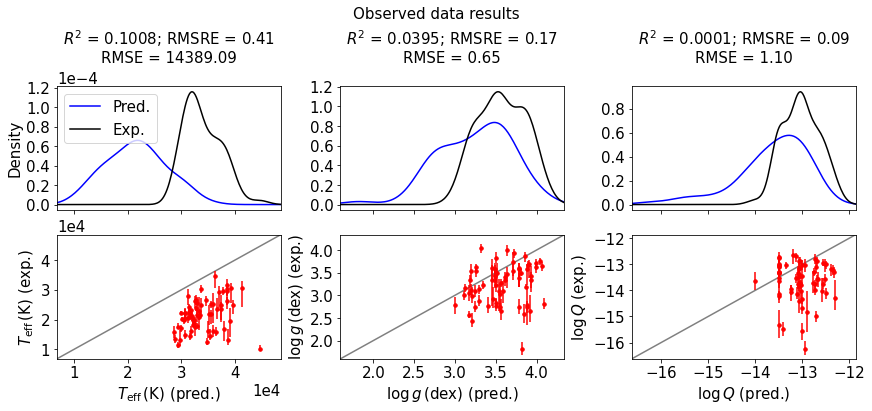

Execution time: 0.1069 (min)


In [47]:
time_start = time()
results_parameters = predict(prediction_parameters)
time_end = time()
results_parameters['y_expected'] = y_observed_test
results_parameters['y_scaler'] = y_scaler
statistics_parameters = analysis(results_parameters)

statistics_parameters['labels'] = labels
statistics_parameters['suptitle'] = 'Observed data results'
statistics_parameters['save'] = None
results(statistics_parameters)

print( f'Execution time: {( time_end - time_start )/60:0.4f} (min)' )

We obtained an excelent performance on synthetic data, but a poor performance on observed data. The reason of this is that our models are not able to generalize for observations. To reduce this, we closed the gap between the synthetic domain and the observed domain using a domain adaptation technique.

## With domain adaptation

We maintain the same architecture of our models, but load weights obtained from a domain adaptation model.

In [49]:
feature_extractor.set_weights( domain_adaptation_model.get_layer( 'feature_extractor' ).get_weights() )

mc_dropout_model = build_mc_dropout_model( task_head, factor=1, replace_bn=True )
mc_dropout_model.set_weights( domain_adaptation_model.get_layer('task_head').get_weights() )

Predictions for deconvolved observed spectra:

In [41]:
prediction_parameters = {
    'model': mc_dropout_model,
    'X': X_observed_test,
    'y_scaler': y_scaler,
    'X_in_shape': X_in_shape_observed,
    'x_scaler': x_scaler,
    'feature_extractor': feature_extractor,
    'fordward_passes': 500,
    'batch_inference': 2**12 # 4096
}

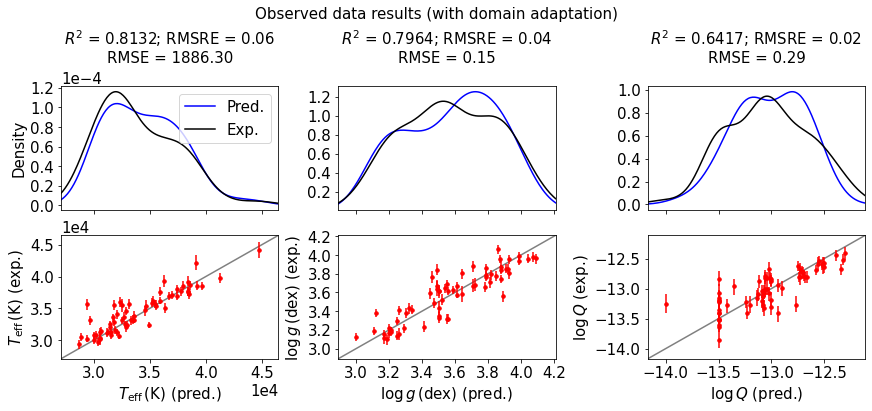

Execution time: 0.1018 (min)


In [44]:
time_start = time()
results_parameters = predict(prediction_parameters)
time_end = time()
results_parameters['y_expected'] = y_observed_test
results_parameters['y_scaler'] = y_scaler
statistics_parameters = analysis(results_parameters)

statistics_parameters['labels'] = labels
statistics_parameters['suptitle'] = 'Observed data results (with domain adaptation)'
statistics_parameters['save'] = None
results(statistics_parameters)

print( f'Execution time: {( time_end - time_start )/60:0.4f} (min)' )

The domain adaptation technique allowed our models to generalize for observations, achieving a good performance when comparing with estimations made with other methods. This was done for a sample of main sequence O-type stars. Generalization for other type of stars, and in different evolutionary stages, will require training data (observations and estimations) from the corresponding type and evolutionary stage.